<a href="https://colab.research.google.com/github/dinda-dwi-lestari/Matematika-Aktuaria/blob/main/projek_aktuaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== DATA  ===
      age  anemia  diabetes  hipertensi  jenis_kelamin  merokok  time  event
0    75.0       0         0           1              1        0     4      1
1    55.0       0         0           0              1        0     6      1
2    65.0       0         0           0              1        1     7      1
3    50.0       1         0           0              1        0     7      1
4    65.0       1         1           0              0        0     8      1
..    ...     ...       ...         ...            ...      ...   ...    ...
294  62.0       0         1           1              1        1   270      0
295  55.0       0         0           0              0        0   271      0
296  45.0       0         1           0              0        0   278      0
297  45.0       0         0           0              1        1   280      0
298  50.0       0         0           0              1        1   285      0

[299 rows x 8 columns]

=== TABEL STATISTIKA DESKRIPTIF ===


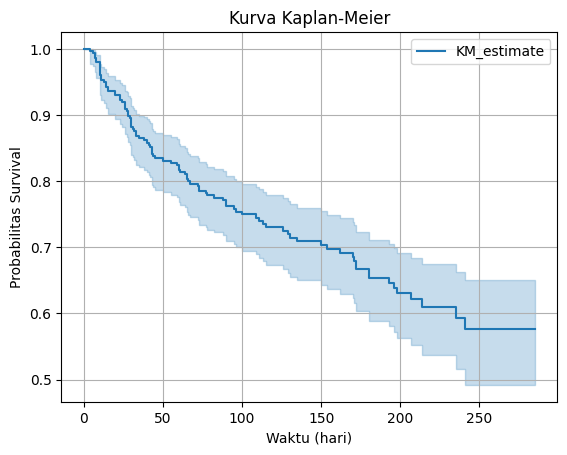

Median Survival: inf


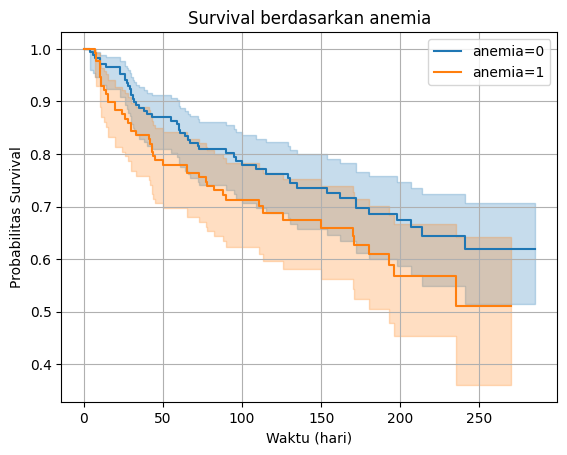

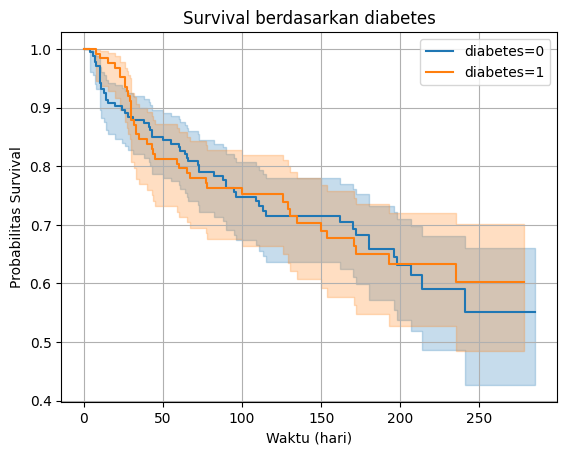

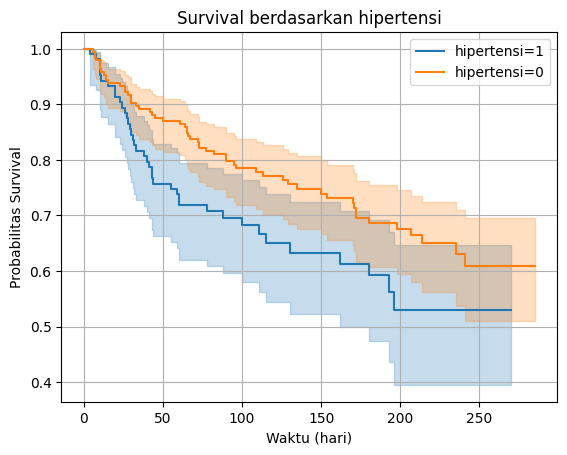

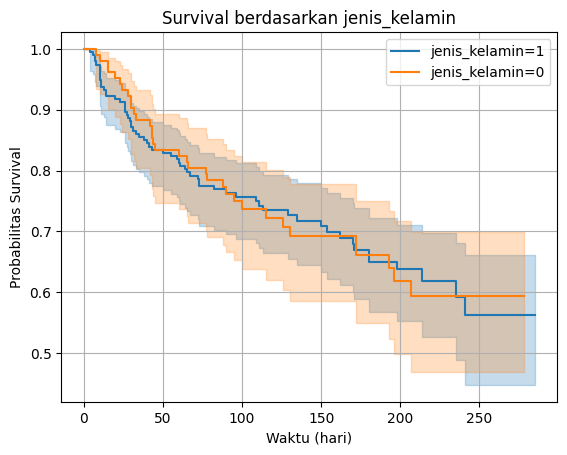

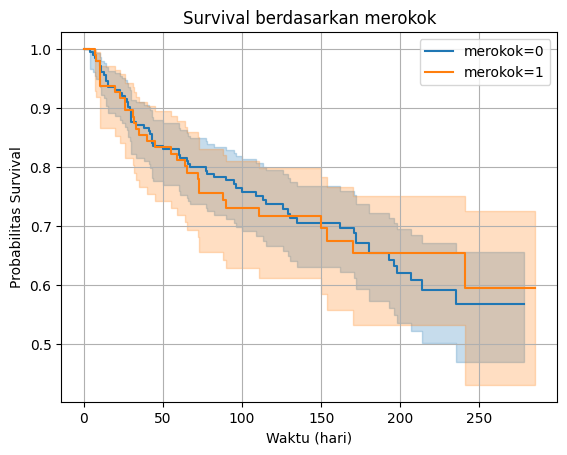


=== TABEL HASIL LOG-RANK ===
        Variabel  p-value  Keputusan
0         Anemia    0.099  Terima H0
1       Diabetes    0.840  Terima H0
2     Hipertensi    0.036   Tolak H0
3  Jenis Kelamin    0.950  Terima H0
4        Merokok    0.964  Terima H0

=== SUMMARY COX PH ===


<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 299
number of events observed = 96
   partial log-likelihood = -505.71
         time fit was run = 2026-04-03 15:04:15 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
anemia         0.34      1.40      0.21           -0.06            0.74                0.94                2.10
diabetes      -0.03      0.97      0.21           -0.44            0.38                0.64                1.46
hipertensi     0.44      1.56      0.21            0.03            0.86                1.03                2.35
jenis_kelamin  0.06      1.06      0.24           -0.42            0.53                0.66                1.70
merokok        0.02      1.02      0.25           -0.46            0.51                0.63                1.67

               cmp to     z    p  -log2(p)
covariate                                 
anemia           0.00  1.65 0.10      3.34
diabetes         0.00 -0.15 0.88      0.18
hipertensi       0.00  2.09 0.04      4.78
jenis_kelamin    0.00  0.23 0.82      0.29
merokok          0.00  0.10 0.92      0.11
---
Concordance = 0.58
Partial AIC = 1021.42
log-likelihood ratio test = 6.99 on 5 df
-log2(p) of ll-ratio test = 2.18


=== TABEL HASIL COX PH ===
        Variabel  Estimasi Parameter  Hazard Ratio
0         Anemia            0.339290      1.403951
1       Diabetes           -0.031461      0.969028
2     Hipertensi            0.441888      1.555642
3  Jenis Kelamin            0.056014      1.057612
4        Merokok            0.023795      1.024081

=== MODEL WEIBULL  ===
                  Value        SE          z              p
const          4.849783  0.124588  38.926554  8.185445e-118
anemia        -0.247273  0.104082  -2.375750   1.815639e-02
diabetes       0.050202  0.105488   0.475904   6.344973e-01
hipertensi    -0.313759  0.107804  -2.910447   3.885929e-03
jenis_kelamin -0.101929  0.121011  -0.842309   4.003022e-01
merokok       -0.013593  0.123177  -0.110350   9.122070e-01

=== TABEL MORTALITAS  ===
   time      S(t)       q_x            l_x         d_x
0   0.0  1.000000  0.000000  100000.000000    0.000000
1   4.0  0.996656  0.003344   99665.551839  333.329605
2   6.0  0.993311  0.003356   

/tmp/ipykernel_1654/1501516413.py:304: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  life_table['q_x'].fillna(0, inplace=True)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test


# ==========================================
# LOAD DATA
# ==========================================
data = pd.read_csv("heart_failure_clinical_records_dataset.csv")
# menghapus data yang tidak diperlukan
data = data.drop(columns=[
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'platelets',
    'serum_sodium',
    'serum_creatinine'
])
#mengubah nama kolom
data = data.rename(columns={
    "anaemia": "anemia",
    "diabetes": "diabetes",
    "high_blood_pressure": "hipertensi",
    "sex": "jenis_kelamin",
    "smoking": "merokok",
    "time": "time",
    "DEATH_EVENT": "event"
})
data['event'] = data['event'].astype(int)
print("\n=== DATA  ===")
print(data)

# ==========================================
# TABEL STATISTIK DESKRIPTIF
# ==========================================
print("\n=== TABEL STATISTIKA DESKRIPTIF ===")

# Variabel numerik
variabel_numerik = {
    'time': 'Time (Hari)',
    'age': 'Age'
}
hasil_deskriptif = []
for col, nama in variabel_numerik.items():
    hasil_deskriptif.append([
        nama,
        data[col].min(),
        data[col].max(),
        round(data[col].mean(), 2),
        data[col].median()
    ])
# DataFrame hasil
tabel_deskriptif = pd.DataFrame(
    hasil_deskriptif,
    columns=['Variabel', 'Min', 'Maks', 'Mean', 'Median']
)
print(tabel_deskriptif)

#------------------------------------------
# Tabel Event vs Censored
#------------------------------------------
print("\n=== TABEL EVENT vs CENSORED ===")

variabel_kategori = {
    'anemia': 'Anemia',
    'diabetes': 'Diabetes',
    'hipertensi': 'High Blood Pressure',
    'jenis_kelamin': 'Sex',
    'merokok': 'Smoking',
}
hasil_event = []
total_data = len(data)

for col, nama in variabel_kategori.items():

    kategori_unik = sorted(data[col].dropna().unique())

    for kategori in kategori_unik:

        subset = data[data[col] == kategori]
        total_kategori = len(subset)

        # Event = meninggal
        meninggal = subset[subset['event'] == 1].shape[0]

        # Censored
        tersensor = subset[subset['event'] == 0].shape[0]

        # Persentase
        persen_meninggal = (meninggal / total_kategori) * 100 if total_kategori > 0 else 0
        persen_tersensor = (tersensor / total_kategori) * 100 if total_kategori > 0 else 0
        persen_total = (total_kategori / total_data) * 100 if total_data > 0 else 0

        hasil_event.append([
            nama,
            "Ya" if kategori == 1 else "Tidak",
            meninggal,
            round(persen_meninggal, 2),
            tersensor,
            round(persen_tersensor, 2),
            total_kategori,
            round(persen_total, 2)
        ])

# DataFrame hasil
tabel_event = pd.DataFrame(
    hasil_event,
    columns=[
        'Variabel',
        'Kategori',
        'Jumlah Meninggal',
        'Persentase Kematian (%)',
        'Jumlah Tersensor',
        'Persentase Tersensor (%)',
        'Total Pasien',
        'Persentase (%)'
    ]
)
print(tabel_event)

# ==========================================
# ANALISIS SURVIVAL
# ==========================================

#------------------------------------------
# Metode Kaplan-Meier
#------------------------------------------
kmf = KaplanMeierFitter()

kmf.fit(
    durations=data['time'],
    event_observed=data['event']
)

# Plot
kmf.plot()
plt.title("Kurva Kaplan-Meier")
plt.xlabel("Waktu (hari)")
plt.ylabel("Probabilitas Survival")
plt.grid()
plt.show()

# Median survival
print("Median Survival:", kmf.median_survival_time_)

# Perbandingan berdasarkan variabel
variabel = ['anemia', 'diabetes', 'hipertensi', 'jenis_kelamin', 'merokok']

for var in variabel:
    plt.figure()
    kmf = KaplanMeierFitter()

    for kategori in data[var].unique():
        subset = data[data[var] == kategori]

        kmf.fit(subset['time'], subset['event'],
                label=f"{var}={kategori}")
        kmf.plot()

    plt.title(f"Survival berdasarkan {var}")
    plt.xlabel("Waktu (hari)")
    plt.ylabel("Probabilitas Survival")
    plt.grid()
    plt.show()

#------------------------------------------
# Uji Log-Rank
#------------------------------------------
def logrank_test_all(data):
    variabel = {
        'anemia': 'Anemia',
        'diabetes': 'Diabetes',
        'hipertensi': 'Hipertensi',
        'jenis_kelamin': 'Jenis Kelamin',
        'merokok': 'Merokok'
    }
    hasil_list = []  # untuk simpan hasil

    for col, nama in variabel.items():
        g0 = data[data[col] == 0]
        g1 = data[data[col] == 1]

        hasil = logrank_test(
            g0['time'], g1['time'],
            event_observed_A=g0['event'],
            event_observed_B=g1['event']
        )

        pval = hasil.p_value
        keputusan = "Tolak H0" if pval < 0.05 else "Terima H0"


        # simpan ke list
        hasil_list.append([nama, round(pval,3), keputusan])

    # buat tabel
    tabel = pd.DataFrame(hasil_list, columns=[
        "Variabel", "p-value", "Keputusan"
    ])

    print("\n=== TABEL HASIL LOG-RANK ===")
    print(tabel)

    return tabel
tabel_logrank = logrank_test_all(data)

#------------------------------------------
# Cox Proportional Hazard
#------------------------------------------
def cox_analysis_full(data):
    # Mapping nama variabel
    variabel = {
        'anemia': 'Anemia',
        'diabetes': 'Diabetes',
        'hipertensi': 'Hipertensi',
        'jenis_kelamin': 'Jenis Kelamin',
        'merokok': 'Merokok'
    }
    data_cox = data[['time', 'event'] + list(variabel.keys())]
    cph = CoxPHFitter()
    cph.fit(data_cox, duration_col='time', event_col='event')

    print("\n=== SUMMARY COX PH ===")
    cph.print_summary()

    # Tabel
    beta = cph.params_
    hr = np.exp(beta)
    pval = cph.summary['p']

    tabel = pd.DataFrame({
        "Variabel": [variabel[v] for v in beta.index],
        "Estimasi Parameter": beta.values,
        "Hazard Ratio": hr.values,
    })

    # Rapikan
    tabel["Estimasi Parameter"] = tabel["Estimasi Parameter"].round(6)
    tabel["Hazard Ratio"] = tabel["Hazard Ratio"].round(6)


    print("\n=== TABEL HASIL COX PH ===")
    print(tabel)

    return tabel
tabel_cox = cox_analysis_full(data)

#------------------------------------------
# MODEL PARAMETRIK WEIBULL
#------------------------------------------
def weibull(data):
    variabel = ['anemia', 'diabetes', 'hipertensi', 'jenis_kelamin', 'merokok']

    # Transformasi Weibull (log time)
    data['log_time'] = np.log(data['time'])

    # Variabel X + konstanta (Intercept)
    X = data[variabel]
    X = sm.add_constant(X)

    # Model regresi
    model = sm.OLS(data['log_time'], X).fit()

    # Ambil hasil
    coef = model.params
    se = model.bse
    z = coef / se
    p = model.pvalues

    # Buat tabel
    tabel = pd.DataFrame({
        "Value": coef,
        "SE": se,
        "z": z,
        "p": p
    })

    print("\n=== MODEL WEIBULL  ===")
    print(tabel)

    return model, tabel
model, tabel = weibull(data)

# ==========================================
# TABEL MORTALITAS
# ==========================================

kmf = KaplanMeierFitter()
kmf.fit(data['time'], data['event'])

# Survival function
survival = kmf.survival_function_

# Buat tabel mortalitas
life_table = survival.reset_index()
life_table.columns = ['time', 'S(t)']

# Hitung qx
life_table['q_x'] = 1 - (life_table['S(t)'] / life_table['S(t)'].shift(1))
life_table['q_x'].fillna(0, inplace=True)

# lx (radix)
l0 = 100000
life_table['l_x'] = l0 * life_table['S(t)']

# dx
life_table['d_x'] = life_table['l_x'] * life_table['q_x']
print("\n=== TABEL MORTALITAS  ===")
print(life_table.head())

# Simpan
life_table.to_csv("tabel_mortalitas.csv", index=False)


# ===============================
# CONTOH HARAPAH HIDUP
# ===============================
def harapan_hidup_pada_waktu(life_table, waktu):
    # Pastikan kolom sudah ada
    life_table['L_x'] = (life_table['l_x'] + life_table['l_x'].shift(-1)) / 2
    life_table['T_x'] = life_table['L_x'][::-1].cumsum()[::-1]
    life_table['e_x'] = life_table['T_x'] / life_table['l_x']

    # Ambil baris terdekat dengan waktu yang diminta
    baris = life_table.iloc[(life_table['time'] - waktu).abs().argsort()[:1]]

    lx = baris['l_x'].values[0]
    Tx = baris['T_x'].values[0]
    ex = baris['e_x'].values[0]

    print(f"\n=== HASIL HARAPAN HIDUP PADA WAKTU {waktu} ===")
    print(f"l_x  = {lx}")
    print(f"T_x  = {Tx}")
    print(f"e_x  = {ex:.2f} hari")

    return ex
ex_67 = harapan_hidup_pada_waktu(life_table, 67)

In [2]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=38614878a8f6156c9df7f5f5f3a67c66a023cc25036832f9216e3bfd5f8a965b
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
